In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import PreTrainedTokenizerFast
import torch
from transformers import BertForMaskedLM, DataCollatorForLanguageModeling
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, random_split
from transformers import DataCollatorForLanguageModeling
from sklearn.model_selection import train_test_split
import os
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jupyter/.local/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
2025-11-19 16:16:55.191023: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `

Датасет

In [2]:
path = '/home/jupyter/datasphere/project/CNN/PRIME_Dataset_plus-minus.csv'
data = pd.read_csv(path)

In [3]:
data['log_mean'] = data['log_mean'] - data['log_mean'].min()

In [4]:
data

,gene_id,mean,log_mean,sequence,-,+
0,AT1G01010,244.885832,2.776282,ACATTTCAAACCACTTGTTCTCTTTTATGTTTTGGTAAGAGCTATC...,"['AT3G22760', 'AT1G35460', 'AT1G51700', 'AT1G2...","['AT1G51140', 'AT2G42280', 'AT4G38620', 'AT1G2..."
1,AT1G01020,367.643741,2.952745,ATCGGATATGACATAGCGGATTTTGTATATCTTTAGAGAGTATGAG...,"['AT3G57920', 'AT4G18960', 'AT1G13450', 'AT1G1...","['AT3G61120', 'AT2G45650', 'AT2G38090', 'AT3G1..."
2,AT1G01030,116.788171,2.454717,TATATAATTTTGATTGAAATTGATGTATACAGCGCAGATGATTTTT...,"['AT4G35550', 'AT1G49480', 'AT1G49480', 'AT3G5...","['AT4G30080', 'AT4G38000', 'AT4G01280', 'AT4G3..."
3,AT1G01040,2077.279230,3.704813,GTGAGGTCCATGTCCACAATAAGAAATCAAATACCAAACAAAGTAT...,"['AT5G13790', 'AT4G18960', 'AT3G57230', 'AT1G7...","['AT5G10140', 'AT5G15800', 'AT3G54340', 'AT1G2..."
4,AT1G01050,1543.546080,3.575838,CTTGTGGACCGCTCATCCTGTGGCTCAAATACACCTTCAGGGAGTG...,"['AT3G46070', 'AT1G51600', 'AT1G69570', 'AT5G4...","['AT2G38090', 'AT2G38090', 'AT4G38910', 'AT2G0..."
...,...,...,...,...,...,...
21180,AT5G67590,1907.232462,3.667722,ATCTTATCCAAACTACAAAAACAGACAATAGCGCAAGATCAAATCT...,"['AT1G70000', 'AT1G74840', 'AT5G08520', 'AT5G0...","['AT1G24260', 'AT2G02080', 'AT1G55110', 'AT2G0..."
21181,AT5G67600,981.665750,3.379282,CAACAAACCAAACTATGTTTGATTATACAGCATCCATATCCCTGAA...,"['AT3G30210', 'AT1G02065', 'AT4G14770', 'AT1G4...","['AT1G13450', 'AT3G24120', 'AT4G11660', 'AT4G1..."
21182,AT5G67610,512.790922,3.097258,GATCCTTAATTTTAGTTCTAGTTGTGACATGATGAATAAGATATTT...,"['AT3G25990', 'AT1G18330', 'AT5G17300', 'AT3G1...","['AT1G32510', 'AT5G18090', 'AT2G38090', 'AT5G0..."
21183,AT5G67620,44.770289,2.038308,TGATATGTATGATTAGGATGTTGAACTCGGATTTATGTTTTTTTTT...,"['AT2G22430', 'AT4G37790', 'AT3G21175', 'AT3G2...","['AT2G18350', 'AT1G69180', 'AT3G24050', 'AT5G5..."


In [5]:
from collections import Counter
import math
def sequence_counter(str_list_cres):
    return math.log10(len(eval(str_list_cres)))

def sequence_entropy(seq):
    counts = Counter(seq)
    total = len(seq)
    entropy = -sum((count/total) * math.log2(count/total) for count in counts.values())
    return entropy

def gc_content(sequence):
    gc_count = sequence.count('G') + sequence.count('C')
    return math.log10(gc_count / len(sequence) * 100)

def unique_cre(sequence):
    return math.log(len(set(eval(sequence))))
    
def find_cpg_islands(sequence, window_size=100, min_length=200, min_gc=50.0, min_obs_exp=0.6):
    """
    Упрощенная версия для быстрого подсчета CpG островков
    """
    if not sequence or len(sequence) < window_size:
        return 0
    
    sequence = sequence.upper()
    n = len(sequence)
    islands = 0
    i = 0
    
    while i <= n - window_size:
        window = sequence[i:i + window_size]
        
        # GC-состав
        gc_content = (window.count('G') + window.count('C')) / window_size * 100
        
        # CpG ratio
        c_count = window.count('C')
        g_count = window.count('G')
        cg_count = sum(1 for j in range(len(window) - 1) if window[j:j+2] == 'CG')
        
        if c_count > 0 and g_count > 0:
            expected_cpg = (c_count * g_count) / window_size
            obs_exp_ratio = cg_count / expected_cpg
        else:
            obs_exp_ratio = 0
        
        if gc_content >= min_gc and obs_exp_ratio >= min_obs_exp:
            islands += 1
            i += window_size  # Перескакиваем окно
        else:
            i += 1
    
    return islands

In [6]:
data['+_len'] = data['+'].map(sequence_counter)
data['-_len'] = data['-'].map(sequence_counter)
data['+_unique'] = data['+'].map(unique_cre)
data['-_unique'] = data['-'].map(unique_cre)
data['GC_cont'] = data['sequence'].map(gc_content)
data['sequence_entropy'] = data['sequence'].map(sequence_entropy)


In [7]:
data['GC_islands'] = data['sequence'].map(find_cpg_islands)

In [8]:
data

,gene_id,mean,log_mean,sequence,-,+,+_len,-_len,+_unique,-_unique,GC_cont,sequence_entropy,GC_islands
0,AT1G01010,244.885832,2.776282,ACATTTCAAACCACTTGTTCTCTTTTATGTTTTGGTAAGAGCTATC...,"['AT3G22760', 'AT1G35460', 'AT1G51700', 'AT1G2...","['AT1G51140', 'AT2G42280', 'AT4G38620', 'AT1G2...",2.271842,2.255273,4.828314,4.795791,1.499171,1.896286,0
1,AT1G01020,367.643741,2.952745,ATCGGATATGACATAGCGGATTTTGTATATCTTTAGAGAGTATGAG...,"['AT3G57920', 'AT4G18960', 'AT1G13450', 'AT1G1...","['AT3G61120', 'AT2G45650', 'AT2G38090', 'AT3G1...",2.320146,2.305351,4.836282,4.905275,1.482516,1.877886,1
2,AT1G01030,116.788171,2.454717,TATATAATTTTGATTGAAATTGATGTATACAGCGCAGATGATTTTT...,"['AT4G35550', 'AT1G49480', 'AT1G49480', 'AT3G5...","['AT4G30080', 'AT4G38000', 'AT4G01280', 'AT4G3...",2.352183,2.301030,5.068904,4.990433,1.467978,1.870136,0
3,AT1G01040,2077.279230,3.704813,GTGAGGTCCATGTCCACAATAAGAAATCAAATACCAAACAAAGTAT...,"['AT5G13790', 'AT4G18960', 'AT3G57230', 'AT1G7...","['AT5G10140', 'AT5G15800', 'AT3G54340', 'AT1G2...",2.271842,2.217484,4.875197,4.787492,1.495718,1.893342,0
4,AT1G01050,1543.546080,3.575838,CTTGTGGACCGCTCATCCTGTGGCTCAAATACACCTTCAGGGAGTG...,"['AT3G46070', 'AT1G51600', 'AT1G69570', 'AT5G4...","['AT2G38090', 'AT2G38090', 'AT4G38910', 'AT2G0...",2.093422,2.096910,4.521789,4.477337,1.557056,1.941922,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21180,AT5G67590,1907.232462,3.667722,ATCTTATCCAAACTACAAAAACAGACAATAGCGCAAGATCAAATCT...,"['AT1G70000', 'AT1G74840', 'AT5G08520', 'AT5G0...","['AT1G24260', 'AT2G02080', 'AT1G55110', 'AT2G0...",2.155336,2.089905,4.770685,4.615121,1.566732,1.938904,0
21181,AT5G67600,981.665750,3.379282,CAACAAACCAAACTATGTTTGATTATACAGCATCCATATCCCTGAA...,"['AT3G30210', 'AT1G02065', 'AT4G14770', 'AT1G4...","['AT1G13450', 'AT3G24120', 'AT4G11660', 'AT4G1...",2.260071,2.267172,4.859812,4.795791,1.523421,1.916002,0
21182,AT5G67610,512.790922,3.097258,GATCCTTAATTTTAGTTCTAGTTGTGACATGATGAATAAGATATTT...,"['AT3G25990', 'AT1G18330', 'AT5G17300', 'AT3G1...","['AT1G32510', 'AT5G18090', 'AT2G38090', 'AT5G0...",2.318063,2.342423,4.934474,4.969813,1.542514,1.931508,1
21183,AT5G67620,44.770289,2.038308,TGATATGTATGATTAGGATGTTGAACTCGGATTTATGTTTTTTTTT...,"['AT2G22430', 'AT4G37790', 'AT3G21175', 'AT3G2...","['AT2G18350', 'AT1G69180', 'AT3G24050', 'AT5G5...",2.346353,2.278754,4.770685,4.718499,1.470741,1.874789,0


<Axes: xlabel='GC_islands', ylabel='Count'>

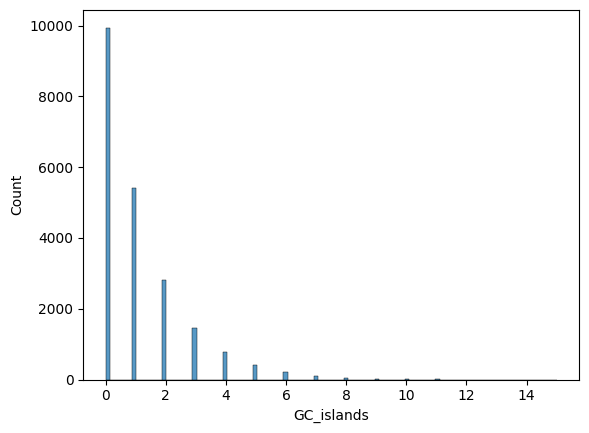

In [9]:
import seaborn as sns

sns.histplot(data['GC_islands'])

In [10]:
data[['+_len', '-_len', '+_unique', '-_unique', 'GC_cont', 'sequence_entropy', 'GC_islands']]

,+_len,-_len,+_unique,-_unique,GC_cont,sequence_entropy,GC_islands
0,2.271842,2.255273,4.828314,4.795791,1.499171,1.896286,0
1,2.320146,2.305351,4.836282,4.905275,1.482516,1.877886,1
2,2.352183,2.301030,5.068904,4.990433,1.467978,1.870136,0
3,2.271842,2.217484,4.875197,4.787492,1.495718,1.893342,0
4,2.093422,2.096910,4.521789,4.477337,1.557056,1.941922,0
...,...,...,...,...,...,...,...
21180,2.155336,2.089905,4.770685,4.615121,1.566732,1.938904,0
21181,2.260071,2.267172,4.859812,4.795791,1.523421,1.916002,0
21182,2.318063,2.342423,4.934474,4.969813,1.542514,1.931508,1
21183,2.346353,2.278754,4.770685,4.718499,1.470741,1.874789,0


In [11]:
X_train, x, y_train, y = train_test_split(data[['+_len', '-_len', '+_unique', '-_unique', 'GC_cont', 'sequence_entropy', 'GC_islands']], data['log_mean'],
                                          train_size=0.7, shuffle=True,
                                          random_state=42)
X_val, X_test, y_val, y_test = train_test_split(x, y,
                                                train_size=0.5, shuffle=True,
                                                random_state=42)

0:	learn: 0.8791890	test: 0.8795328	best: 0.8795328 (0)	total: 55.8ms	remaining: 9m 17s
100:	learn: 0.8595710	test: 0.8761600	best: 0.8756869 (73)	total: 304ms	remaining: 29.8s
200:	learn: 0.8425713	test: 0.8778763	best: 0.8756869 (73)	total: 556ms	remaining: 27.1s
300:	learn: 0.8263486	test: 0.8804092	best: 0.8756869 (73)	total: 802ms	remaining: 25.9s
400:	learn: 0.8125031	test: 0.8829109	best: 0.8756869 (73)	total: 1.05s	remaining: 25.2s
500:	learn: 0.7988840	test: 0.8854473	best: 0.8756869 (73)	total: 1.3s	remaining: 24.7s
600:	learn: 0.7869987	test: 0.8878617	best: 0.8756869 (73)	total: 1.55s	remaining: 24.2s
700:	learn: 0.7756045	test: 0.8896872	best: 0.8756869 (73)	total: 1.79s	remaining: 23.8s
800:	learn: 0.7650781	test: 0.8906718	best: 0.8756869 (73)	total: 2.03s	remaining: 23.4s
900:	learn: 0.7553859	test: 0.8927781	best: 0.8756869 (73)	total: 2.28s	remaining: 23.1s
1000:	learn: 0.7466238	test: 0.8943073	best: 0.8756869 (73)	total: 2.53s	remaining: 22.7s
1100:	learn: 0.7368469

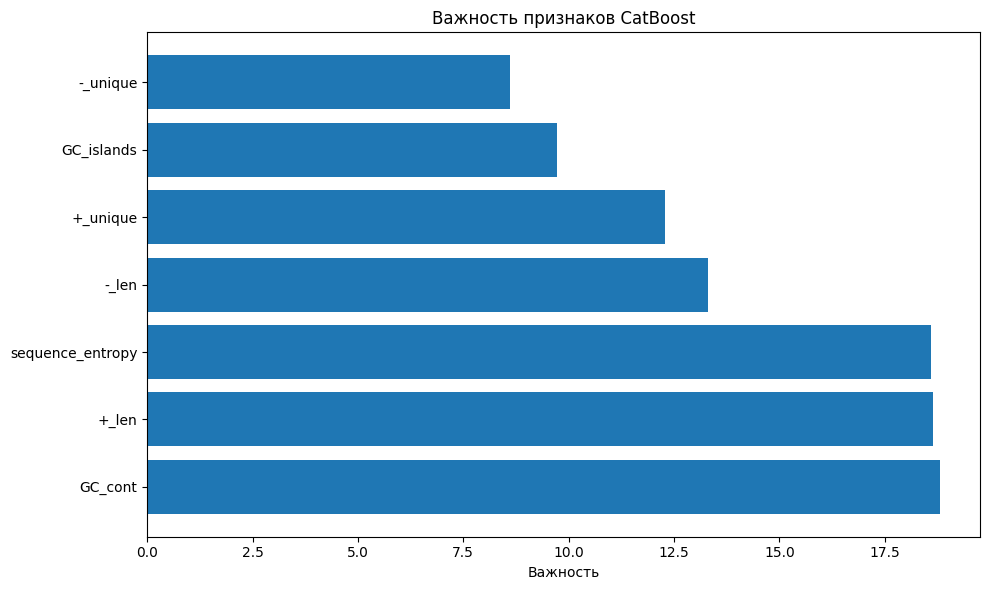

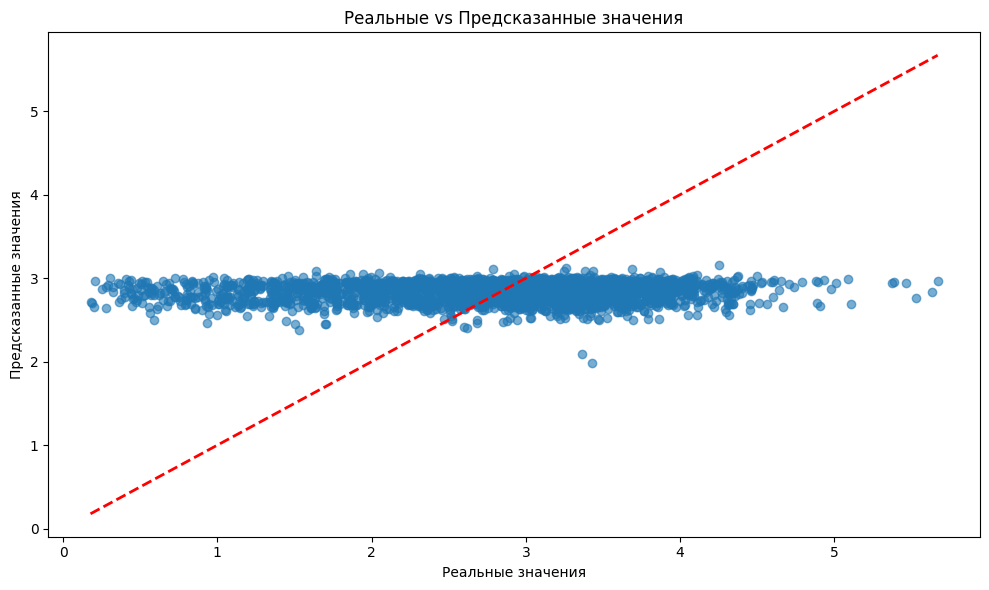


Модель сохранена как: catboost_regression_model.cbm


In [12]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Инициализация модели CatBoost для регрессии
model = CatBoostRegressor(
    iterations=10000,           # Количество деревьев
    learning_rate=0.1,         # Скорость обучения
    depth=6,                   # Глубина деревьев
    eval_metric='RMSE',        # Метрика для валидации
    early_stopping_rounds=None, #Ранняя остановка
    random_state=42,           # Для воспроизводимости
    verbose=100,               # Вывод каждые 100 итераций
    # task_type='GPU',         # Раскомментируйте для использования GPU
    # cat_features=cat_features  # Укажите список категориальных признаков если есть
)

# Обучение модели
model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
    plot=False  # Установите True для визуализации процесса обучения
)

# Прогнозирование на тестовых данных
y_pred = model.predict(X_test)

# Оценка модели на тестовой выборке
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print('=' * 50)
print('Результаты на тестовой выборке:')
print(f'RMSE: {rmse:.4f}')
print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R²: {r2:.4f}')
print('=' * 50)

# Важность признаков
feature_importances = model.get_feature_importance()
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature_{i}' for i in range(X_train.shape[1])]

print('\nВажность признаков:')
for name, importance in zip(feature_names, feature_importances):
    print(f'{name}: {importance:.4f}')

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
indices = np.argsort(feature_importances)[::-1]
plt.barh(range(len(feature_importances)), feature_importances[indices])
plt.yticks(range(len(feature_importances)), [feature_names[i] for i in indices])
plt.xlabel('Важность')
plt.title('Важность признаков CatBoost')
plt.tight_layout()
plt.show()

# Сравнение предсказаний с реальными значениями
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Реальные vs Предсказанные значения')
plt.tight_layout()
plt.show()

# Сохранение модели
model.save_model('catboost_regression_model.cbm')
print('\nМодель сохранена как: catboost_regression_model.cbm')

# Загрузка модели (пример)
# loaded_model = CatBoostRegressor()
# loaded_model.load_model('catboost_regression_model.cbm')